In [6]:
import os
import zipfile
import rasterio
import numpy as np
import matplotlib.pyplot as plt


Mount Google Drive

In [7]:
# from google.colab import drive

# drive.mount('/content/drive')

3. Checking Dataset folder

In [8]:
from pathlib import Path
dataset_folder = "Data/Bhoonidhi_Dataset"

print("Files in dataset folder:")
print(os.listdir(dataset_folder))

Files in dataset folder:
['extracted', 'RAF03AUG2025044914011100053SSANSTUC00GTDB']


4. Define zipfile extraction & location

In [9]:
from pathlib import Path

zip_path = Path(
    "Data/Bhoonidhi_Dataset/RAF03AUG2025044914011100053SSANSTUC00GTDB.zip"
)

extract_path = Path("extracted")

print("ZIP file:", zip_path)
print("Extraction folder:", extract_path)


ZIP file: Data\Bhoonidhi_Dataset\RAF03AUG2025044914011100053SSANSTUC00GTDB.zip
Extraction folder: extracted


In [11]:
from pathlib import Path

print("Current working directory:")
print(Path.cwd())

print("\nSearching for ZIP files...")

zip_files = list(Path.cwd().rglob("*.zip"))

for zip_file in zip_files:
    print(zip_file)


Current working directory:
c:\Users\LENOVO\OneDrive\Documents\Desktop\Major-project

Searching for ZIP files...


5. Extract the Zip

In [14]:
from pathlib import Path
import os

dataset_folder = Path(
    "Data/Bhoonidhi_Dataset/RAF03AUG2025044914011100053SSANSTUC00GTDB"
)

print("Dataset folder:", dataset_folder)
print("Exists:", dataset_folder.exists())

print("\nFiles:")
for file in dataset_folder.iterdir():
    print(file.name)


Dataset folder: Data\Bhoonidhi_Dataset\RAF03AUG2025044914011100053SSANSTUC00GTDB
Exists: True

Files:
ACC_REP.txt
BAND2.tif
BAND3.tif
BAND4.tif
BAND_META.txt
RAF03AUG2025044914011100053SSANSTUC00GTDB.jpg
RAF03AUG2025044914011100053SSANSTUC00GTDB.jpg.aux.xml
RAF03AUG2025044914011100053SSANSTUC00GTDB.meta


 6. Find all TIFF files automatically

In [15]:
tif_files = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".tif", ".tiff")):
            tif_files.append(os.path.join(root, file))

print(f"Total TIFF files found: {len(tif_files)}")

for i, tif in enumerate(tif_files):
    print(i, tif)

Total TIFF files found: 0


7. Inspect the TIFF files

In [16]:
for tif in tif_files:

    with rasterio.open(tif) as src:

        print("\n" + "=" * 70)
        print("File:", os.path.basename(tif))
        print("Width:", src.width)
        print("Height:", src.height)
        print("Bands:", src.count)
        print("Data type:", src.dtypes)
        print("CRS:", src.crs)
        print("Resolution:", src.res)
        print("NoData:", src.nodata)
        print("Minimum:", src.read(1).min())
        print("Maximum:", src.read(1).max())


8. Automatically locate B2, B3 and B4

In [17]:
band_paths = {}

for tif in tif_files:

    filename = os.path.basename(tif).upper()

    if "BAND2" in filename:
        band_paths["B2"] = tif

    elif "BAND3" in filename:
        band_paths["B3"] = tif

    elif "BAND4" in filename:
        band_paths["B4"] = tif


print("Detected bands:")

for band_name, path in band_paths.items():
    print(band_name, "→", path)

Detected bands:


9. Check that all three bands were found

In [18]:
required_bands = ["B2", "B3", "B4"]

for band in required_bands:

    if band not in band_paths:
        raise FileNotFoundError(
            f"{band} was not found in the extracted dataset."
        )

print("All three required bands were found successfully.")

FileNotFoundError: B2 was not found in the extracted dataset.

10. Create the preprocessing function

In [ ]:
def enhance_band(path, scale=8):

    with rasterio.open(path) as src:

        band = src.read(
            1,
            out_shape=(
                src.height // scale,
                src.width // scale
            ),
            resampling=rasterio.enums.Resampling.average
        ).astype(np.float32)

    valid = band[band > 0]

    if len(valid) == 0:
        raise ValueError(f"No valid pixels found in {path}")

    low = np.percentile(valid, 2)
    high = np.percentile(valid, 98)

    if high <= low:
        raise ValueError(f"Invalid contrast range for {path}")

    enhanced = np.clip(
        (band - low) / (high - low),
        0,
        1
    )

    return enhanced

Checking bands before extracting:

In [ ]:
for name, path in band_paths.items():
    with rasterio.open(path) as src:
        print(name)
        print("Size:", src.width, src.height)
        print("CRS:", src.crs)
        print("Resolution:", src.res)
        print("Dtype:", src.dtypes[0])
        print()

B4
Size: 18129 16429
CRS: PROJCS["WGS 84 / UTM zone 46N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722293287,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",93],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32646"]]
Resolution: (5.0, 5.0)
Dtype: uint16

B2
Size: 18129 16429
CRS: PROJCS["WGS 84 / UTM zone 46N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722293287,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PA

11. Process the three bands

In [ ]:
band2 = enhance_band(band_paths["B2"])
band3 = enhance_band(band_paths["B3"])
band4 = enhance_band(band_paths["B4"])

print("B2 shape:", band2.shape)
print("B3 shape:", band3.shape)
print("B4 shape:", band4.shape)

B2 shape: (2053, 2266)
B3 shape: (2053, 2266)
B4 shape: (2053, 2266)


12. Check individual bands

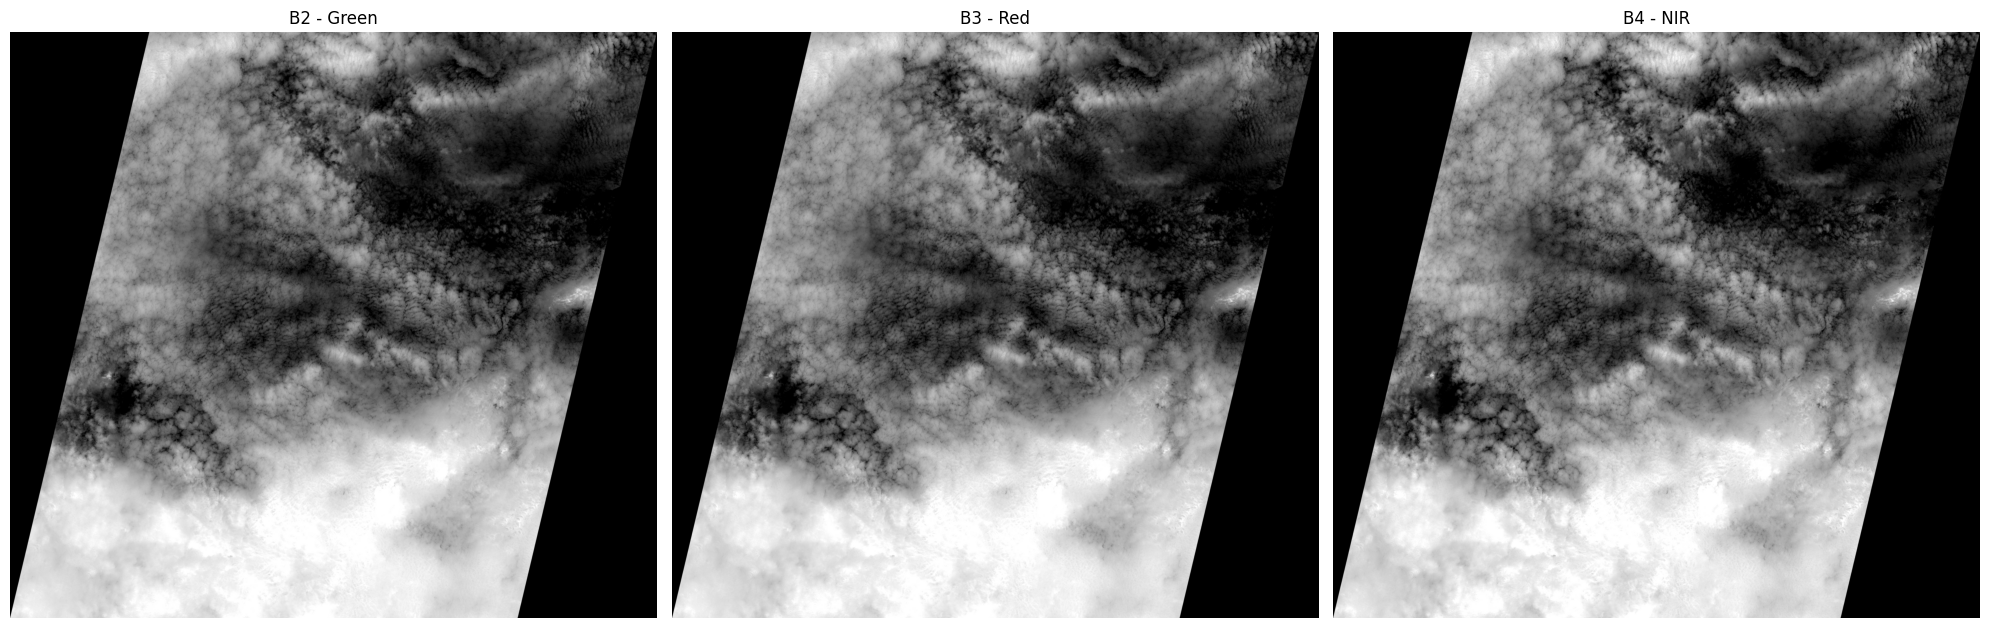

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].imshow(band2, cmap="gray")
axes[0].set_title("B2 - Green")
axes[0].axis("off")

axes[1].imshow(band3, cmap="gray")
axes[1].set_title("B3 - Red")
axes[1].axis("off")

axes[2].imshow(band4, cmap="gray")
axes[2].set_title("B4 - NIR")
axes[2].axis("off")

plt.tight_layout()
plt.show()

13. creating the FCC

In [ ]:
# False Colour Composite
#
# B4 (NIR)   → Red
# B3 (Red)   → Green
# B2 (Green) → Blue

fcc = np.stack(
    [band4, band3, band2],
    axis=-1
)

print("FCC shape:", fcc.shape)
print("FCC range:", fcc.min(), "to", fcc.max())

FCC shape: (2053, 2266, 3)
FCC range: 0.0 to 1.0


14. Display the FCC

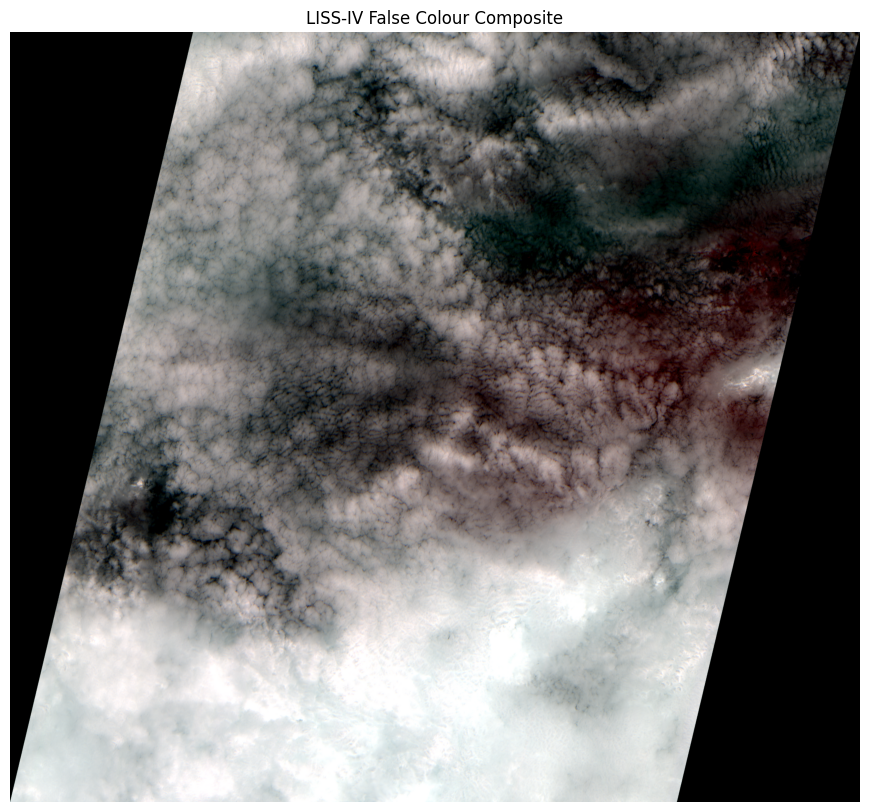

In [ ]:
plt.figure(figsize=(14, 10))

plt.imshow(fcc)

plt.title("LISS-IV False Colour Composite")
plt.axis("off")

plt.show()

15. Create the output folder

In [ ]:
result_folder = "/content/processed"

os.makedirs(result_folder, exist_ok=True)

print("Output folder:", result_folder)

Output folder: /content/processed


16. Save the FCC as GeoTIFF

In [ ]:
output_path = os.path.join(
    result_folder,
    "LISS_IV_FCC.tif"
)

with rasterio.open(band_paths["B2"]) as src:

    profile = src.profile.copy()

    # Calculate new transform for reduced resolution
    scale_x = src.width / fcc.shape[1]
    scale_y = src.height / fcc.shape[0]

    new_transform = src.transform * rasterio.Affine.scale(
        scale_x,
        scale_y
    )

    # Remove source-specific tiling/block settings
    profile.pop("blockxsize", None)
    profile.pop("blockysize", None)

    profile.update(
        driver="GTiff",
        count=3,
        dtype="float32",
        width=fcc.shape[1],
        height=fcc.shape[0],
        transform=new_transform,
        compress="deflate"
    )

    with rasterio.open(output_path, "w", **profile) as dst:

        dst.write(fcc[:, :, 0], 1)  # Red = B4
        dst.write(fcc[:, :, 1], 2)  # Green = B3
        dst.write(fcc[:, :, 2], 3)  # Blue = B2

print("FCC saved successfully!")
print(output_path)

FCC saved successfully!
/content/processed/LISS_IV_FCC.tif


17. Check that the output exists

In [ ]:
print(os.path.exists(output_path))
print(os.path.getsize(output_path) / (1024 * 1024), "MB")

True
18.977946281433105 MB


18. Creating folder for stage 2

In [ ]:
patch_root = "/content/liss_iv_dataset"

clear_dir = os.path.join(patch_root, "clear")
preview_dir = os.path.join(patch_root, "previews")

os.makedirs(clear_dir, exist_ok=True)
os.makedirs(preview_dir, exist_ok=True)

19. Verify the band:

In [ ]:
# Open the original-resolution LISS-IV bands

src_b2 = rasterio.open(band_paths["B2"])
src_b3 = rasterio.open(band_paths["B3"])
src_b4 = rasterio.open(band_paths["B4"])

print("B2:", src_b2.width, src_b2.height)
print("B3:", src_b3.width, src_b3.height)
print("B4:", src_b4.width, src_b4.height)

B2: 18129 16429
B3: 18129 16429
B4: 18129 16429


19. Testing the ONE 256x256 patch

In [ ]:
from rasterio.windows import Window

patch_size = 256

row = 0
col = 0

window = Window(
    col,
    row,
    patch_size,
    patch_size
)

b2 = src_b2.read(1, window=window)
b3 = src_b3.read(1, window=window)
b4 = src_b4.read(1, window=window)

print("B2 shape:", b2.shape)
print("B3 shape:", b3.shape)
print("B4 shape:", b4.shape)

B2 shape: (256, 256)
B3 shape: (256, 256)
B4 shape: (256, 256)


20. Extract 256x256 patches:

In [ ]:
patch_size = 256
stride = 256

print("Patch size:", patch_size)
print("Stride:", stride)

Patch size: 256
Stride: 256


20. Check B2, B3 and B4 allignment

In [ ]:
for band_name in ["B2", "B3", "B4"]:
    path = band_paths[band_name]

    with rasterio.open(path) as src:
        print(f"\n{band_name}")
        print("Width:", src.width)
        print("Height:", src.height)
        print("Resolution:", src.res)
        print("CRS:", src.crs)
        print("Transform:", src.transform)


B2
Width: 18129
Height: 16429
Resolution: (5.0, 5.0)
CRS: PROJCS["WGS 84 / UTM zone 46N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722293287,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",93],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32646"]]
Transform: | 5.00, 0.00, 450343.94|
| 0.00,-5.00, 2966852.50|
| 0.00, 0.00, 1.00|

B3
Width: 18129
Height: 16429
Resolution: (5.0, 5.0)
CRS: PROJCS["WGS 84 / UTM zone 46N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.25722293287,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["E

21. Calculate normalization values:

In [ ]:
band_stats = {}

for band_name in ["B2", "B3", "B4"]:
    path = band_paths[band_name]

    with rasterio.open(path) as src:
        data = src.read(1)

    valid = data[data > 0]

    low = np.percentile(valid, 2)
    high = np.percentile(valid, 98)

    band_stats[band_name] = {
        "low": low,
        "high": high
    }

    print(
        band_name,
        "low =", low,
        "high =", high
    )

B2 low = 215.0 high = 898.0


B3 low = 197.0 high = 901.0
B4 low = 285.0 high = 865.0


22. Check whether this patch is usable

In [ ]:
valid_mask = (
    (b2 > 0) &
    (b3 > 0) &
    (b4 > 0)
)

valid_fraction = valid_mask.mean()

print("Valid pixels:", valid_fraction * 100, "%")

Valid pixels: 0.0 %


In [ ]:
print("B2:")
print("Min:", b2.min())
print("Max:", b2.max())
print("Non-zero pixels:", np.count_nonzero(b2))

print("\nB3:")
print("Min:", b3.min())
print("Max:", b3.max())
print("Non-zero pixels:", np.count_nonzero(b3))

print("\nB4:")
print("Min:", b4.min())
print("Max:", b4.max())
print("Non-zero pixels:", np.count_nonzero(b4))

B2:
Min: 0
Max: 0
Non-zero pixels: 0

B3:
Min: 0
Max: 0
Non-zero pixels: 0

B4:
Min: 0
Max: 0
Non-zero pixels: 0


In [ ]:
print("B2 NoData:", src_b2.nodata)
print("B3 NoData:", src_b3.nodata)
print("B4 NoData:", src_b4.nodata)

B2 NoData: None
B3 NoData: None
B4 NoData: None


In [ ]:
# Check the image at different positions

test_positions = [
    (0, 0),
    (0, 2000),
    (2000, 0),
    (2000, 2000),
    (4000, 4000),
    (8000, 8000),
    (12000, 12000)
]

for row, col in test_positions:

    window = Window(col, row, 256, 256)

    b2_test = src_b2.read(1, window=window)
    b3_test = src_b3.read(1, window=window)
    b4_test = src_b4.read(1, window=window)

    valid = (
        (b2_test > 0) &
        (b3_test > 0) &
        (b4_test > 0)
    )

    print(
        f"Row={row}, Col={col} "
        f"→ Valid={valid.mean()*100:.2f}% "
        f"| B2 max={b2_test.max()} "
        f"| B3 max={b3_test.max()} "
        f"| B4 max={b4_test.max()}"
    )

Row=0, Col=0 → Valid=0.00% | B2 max=0 | B3 max=0 | B4 max=0
Row=0, Col=2000 → Valid=0.00% | B2 max=0 | B3 max=0 | B4 max=0
Row=2000, Col=0 → Valid=0.00% | B2 max=0 | B3 max=0 | B4 max=0
Row=2000, Col=2000 → Valid=0.00% | B2 max=0 | B3 max=0 | B4 max=0
Row=4000, Col=4000 → Valid=100.00% | B2 max=641 | B3 max=640 | B4 max=656
Row=8000, Col=8000 → Valid=100.00% | B2 max=444 | B3 max=438 | B4 max=503
Row=12000, Col=12000 → Valid=100.00% | B2 max=1022 | B3 max=1023 | B4 max=1023


In [ ]:
from rasterio.windows import Window
import numpy as np

patch_size = 256
stride = 256

# Scene-level normalization values
norm_stats = {
    "B2": (215.0, 898.0),
    "B3": (197.0, 901.0),
    "B4": (285.0, 865.0)
}

valid_threshold = 0.90

test_count = 0

for row in range(0, src_b2.height - patch_size + 1, stride):

    for col in range(0, src_b2.width - patch_size + 1, stride):

        window = Window(col, row, patch_size, patch_size)

        b2 = src_b2.read(1, window=window)
        b3 = src_b3.read(1, window=window)
        b4 = src_b4.read(1, window=window)

        valid_mask = (
            (b2 > 0) &
            (b3 > 0) &
            (b4 > 0)
        )

        valid_fraction = valid_mask.mean()

        if valid_fraction >= valid_threshold:

            print(
                f"Found valid patch → "
                f"Row={row}, Col={col}, "
                f"Valid={valid_fraction*100:.2f}%"
            )

            test_count += 1

            if test_count == 10:
                break

    if test_count == 10:
        break

print("\nTotal test patches found:", test_count)

Found valid patch → Row=0, Col=4096, Valid=100.00%
Found valid patch → Row=0, Col=4352, Valid=100.00%
Found valid patch → Row=0, Col=4608, Valid=100.00%
Found valid patch → Row=0, Col=4864, Valid=100.00%
Found valid patch → Row=0, Col=5120, Valid=100.00%
Found valid patch → Row=0, Col=5376, Valid=100.00%
Found valid patch → Row=0, Col=5632, Valid=100.00%
Found valid patch → Row=0, Col=5888, Valid=100.00%
Found valid patch → Row=0, Col=6144, Valid=100.00%
Found valid patch → Row=0, Col=6400, Valid=100.00%

Total test patches found: 10


In [ ]:
from rasterio.windows import Window
import numpy as np
import os

# -----------------------------
# Patch settings
# -----------------------------
patch_size = 256
stride = 256

# Only keep patches where at least 90% of pixels
# are valid in all three bands
valid_threshold = 0.90

# -----------------------------
# Normalization values
# -----------------------------
norm_stats = {
    "B2": (215.0, 898.0),
    "B3": (197.0, 901.0),
    "B4": (285.0, 865.0)
}

# -----------------------------
# Output folder
# -----------------------------
clear_dir = "/content/liss_iv_dataset/clear"
os.makedirs(clear_dir, exist_ok=True)

# -----------------------------
# Helper function
# -----------------------------
def normalize_band(band, low, high):
    band = band.astype(np.float32)

    band = (band - low) / (high - low)

    band = np.clip(band, 0, 1)

    return band


# -----------------------------
# Extract patches
# -----------------------------
patch_count = 0
skipped_count = 0

for row in range(0, src_b2.height - patch_size + 1, stride):

    for col in range(0, src_b2.width - patch_size + 1, stride):

        window = Window(
            col,
            row,
            patch_size,
            patch_size
        )

        # Read all three bands
        b2 = src_b2.read(1, window=window)
        b3 = src_b3.read(1, window=window)
        b4 = src_b4.read(1, window=window)

        # -----------------------------
        # Valid pixel mask
        # -----------------------------
        valid_mask = (
            (b2 > 0) &
            (b3 > 0) &
            (b4 > 0)
        )

        valid_fraction = valid_mask.mean()

        # Skip mostly-empty patches
        if valid_fraction < valid_threshold:
            skipped_count += 1
            continue

        # -----------------------------
        # Normalize
        # -----------------------------
        b2_norm = normalize_band(
            b2,
            norm_stats["B2"][0],
            norm_stats["B2"][1]
        )

        b3_norm = normalize_band(
            b3,
            norm_stats["B3"][0],
            norm_stats["B3"][1]
        )

        b4_norm = normalize_band(
            b4,
            norm_stats["B4"][0],
            norm_stats["B4"][1]
        )

        # -----------------------------
        # Stack channels
        # B2, B3, B4
        # -----------------------------
        patch = np.stack(
            [b2_norm, b3_norm, b4_norm],
            axis=0
        ).astype(np.float32)

        # -----------------------------
        # Save
        # -----------------------------
        patch_filename = f"clear_{patch_count:05d}.npy"

        patch_path = os.path.join(
            clear_dir,
            patch_filename
        )

        np.save(patch_path, patch)

        patch_count += 1

print("Patch extraction complete!")
print("Valid patches saved:", patch_count)
print("Patches skipped:", skipped_count)

Patch extraction complete!
Valid patches saved: 3504
Patches skipped: 976


Number of patches: 3504


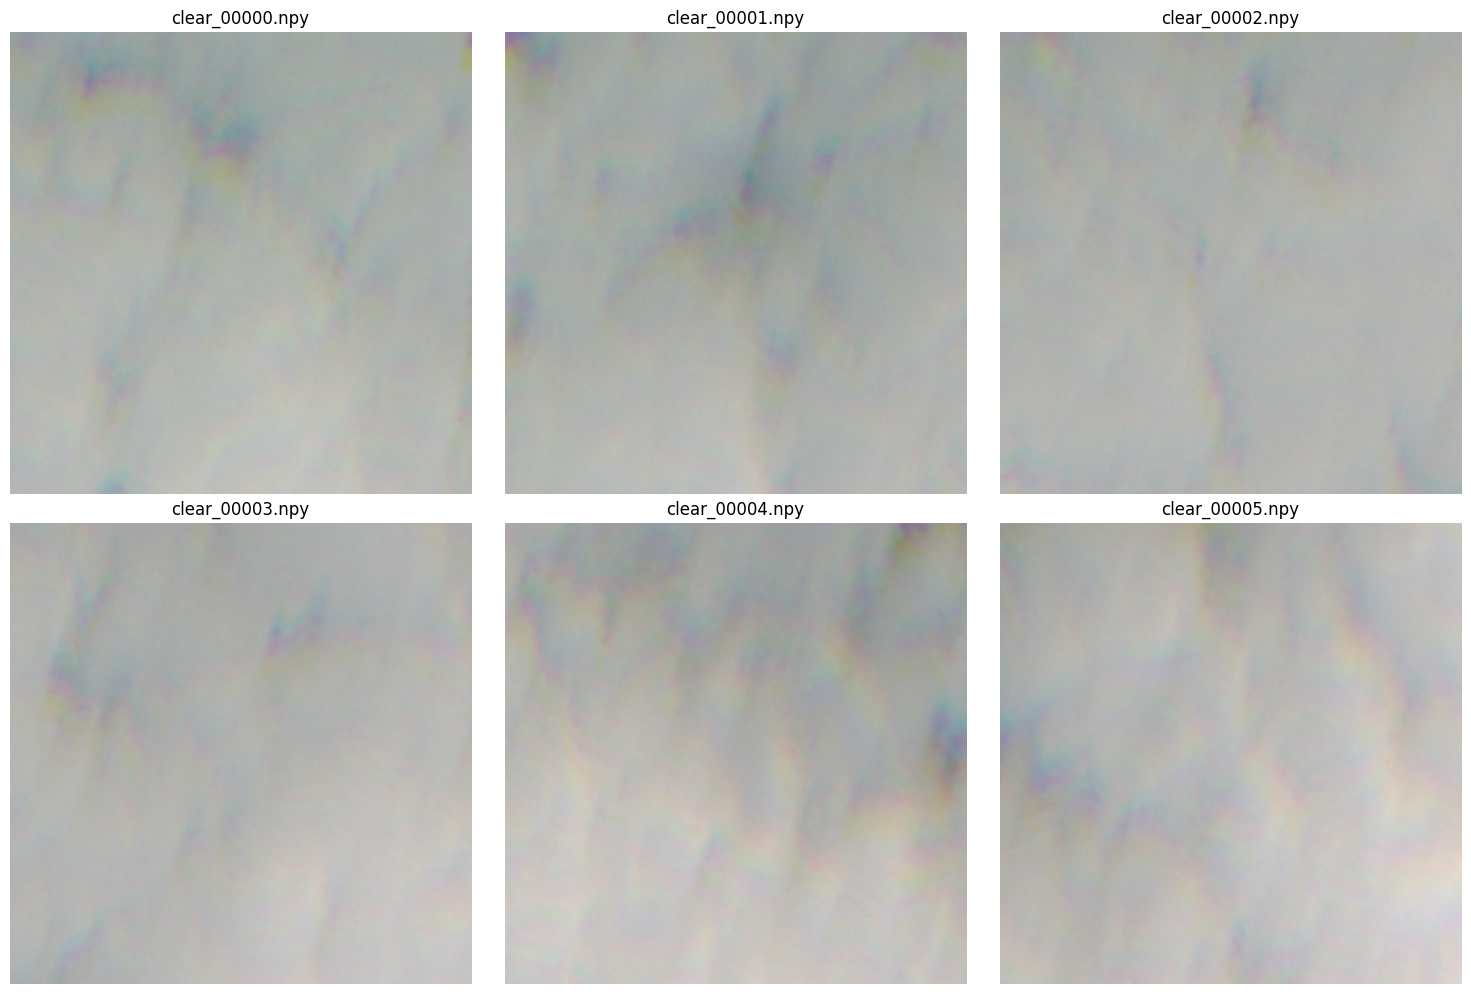

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

clear_dir = "/content/liss_iv_dataset/clear"

# Get saved patches
patch_files = sorted([
    f for f in os.listdir(clear_dir)
    if f.endswith(".npy")
])

print("Number of patches:", len(patch_files))

# Pick a few patches
sample_files = patch_files[:6]

plt.figure(figsize=(15, 10))

for i, filename in enumerate(sample_files):

    patch = np.load(
        os.path.join(clear_dir, filename)
    )

    # B2, B3, B4
    b2 = patch[0]
    b3 = patch[1]
    b4 = patch[2]

    # FCC = B4, B3, B2
    fcc = np.stack(
        [b4, b3, b2],
        axis=-1
    )

    plt.subplot(2, 3, i + 1)
    plt.imshow(fcc)
    plt.title(filename)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
import numpy as np

clear_dir = "/content/liss_iv_dataset/clear"

for filename in ["clear_00000.npy", "clear_00001.npy", "clear_00002.npy"]:

    patch = np.load(os.path.join(clear_dir, filename))

    print("\n", filename)
    print("Shape:", patch.shape)

    for i, band in enumerate(["B2", "B3", "B4"]):
        data = patch[i]

        print(
            band,
            "| min =", round(data.min(), 4),
            "| max =", round(data.max(), 4),
            "| mean =", round(data.mean(), 4),
            "| p2 =", round(np.percentile(data, 2), 4),
            "| p98 =", round(np.percentile(data, 98), 4)
        )


 clear_00000.npy
Shape: (3, 256, 256)
B2 | min = 0.451 | max = 0.7672 | mean = 0.6721 | p2 = 0.5915 | p98 = 0.7408
B3 | min = 0.5 | max = 0.7884 | mean = 0.6908 | p2 = 0.6051 | p98 = 0.7614
B4 | min = 0.4569 | max = 0.7879 | mean = 0.6727 | p2 = 0.5672 | p98 = 0.7586

 clear_00001.npy
Shape: (3, 256, 256)
B2 | min = 0.4612 | max = 0.7511 | mean = 0.6512 | p2 = 0.5681 | p98 = 0.7247
B3 | min = 0.4588 | max = 0.7727 | mean = 0.6661 | p2 = 0.5767 | p98 = 0.7386
B4 | min = 0.419 | max = 0.7845 | mean = 0.6484 | p2 = 0.5431 | p98 = 0.7379

 clear_00002.npy
Shape: (3, 256, 256)
B2 | min = 0.5417 | max = 0.7233 | mean = 0.676 | p2 = 0.6135 | p98 = 0.7101
B3 | min = 0.5497 | max = 0.7358 | mean = 0.6889 | p2 = 0.6307 | p98 = 0.7216
B4 | min = 0.5172 | max = 0.7431 | mean = 0.6795 | p2 = 0.6103 | p98 = 0.7207


In [ ]:


clear_dir = "/content/liss_iv_dataset/clear"

sample_files = [
    "clear_00000.npy",
    "clear_00001.npy",
    "clear_00002.npy",
    "clear_00100.npy",
    "clear_01000.npy",
    "clear_02000.npy"
]

def stretch_for_display(band):
    low = np.percentile(band, 2)
    high = np.percentile(band, 98)

    band = (band - low) / (high - low + 1e-8)
    return np.clip(band, 0, 1)


plt.figure(figsize=(15, 10))

for i, filename in enumerate(sample_files):

    patch = np.load(
        os.path.join(clear_dir, filename)
    )

    b2 = patch[0]
    b3 = patch[1]
    b4 = patch[2]

    # Local stretch ONLY for visualization
    b2_display = stretch_for_display(b2)
    b3_display = stretch_for_display(b3)
    b4_display = stretch_for_display(b4)

    # FCC = B4, B3, B2
    fcc = np.stack(
        [b4_display, b3_display, b2_display],
        axis=-1
    )

    plt.subplot(2, 3, i + 1)
    plt.imshow(fcc)
    plt.title(filename)
    plt.axis("off")

plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.